In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2024, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #3198: 1610
Sim #7471: 1580
Sim #695: 1570
Sim #1719: 1550
Sim #3711: 1550

BOTTOM 5 SCORES
Sim #5533: 190
Sim #6065: 200
Sim #7289: 220
Sim #2555: 230
Sim #4228: 230

AVERAGE SCORE: 709.36


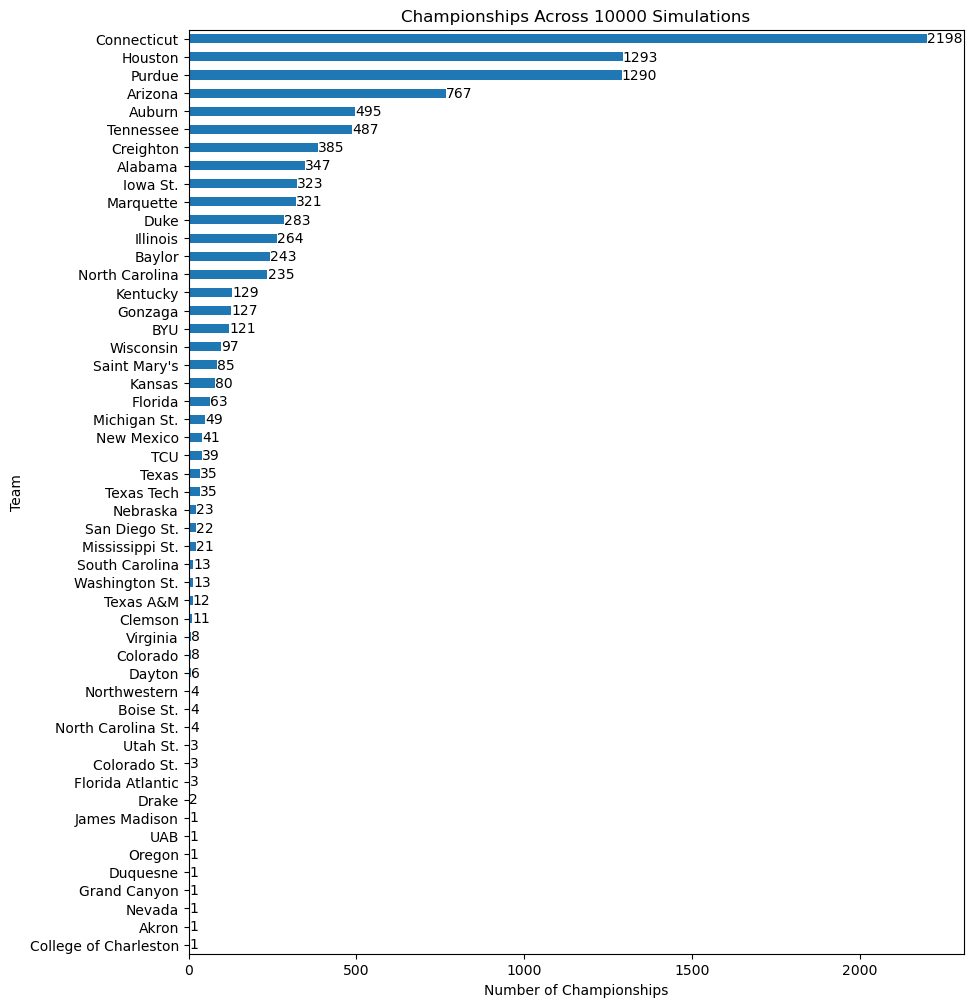

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Connecticut       2198 --> 21.98%          TCU                39 --> 0.39%            James Madison       1 --> 0.01%         
Houston           1293 --> 12.93%          Texas Tech         35 --> 0.35%            Grand Canyon        1 --> 0.01%         
Purdue            1290 --> 12.9%           Texas              35 --> 0.35%            UAB                 1 --> 0.01%         
Arizona           767 --> 7.67%            Nebraska           23 --> 0.23%            College of Charleston   1 --> 0.01%     
Auburn            495 --> 4.95%            San Diego St.      22 --> 0.22%            Akron               1 --> 0.01%         
Tennessee         487 --> 4.87%            Mississippi St.    21 --> 0.21%            McNeese St.         0 --> 0.0%          
Creighton         385 --> 3.85%            South Carolina     13 --> 0.13%            Samford             0 --> 0.0%          
Alabama           347 --> 3.47%            Washington St.     13 -

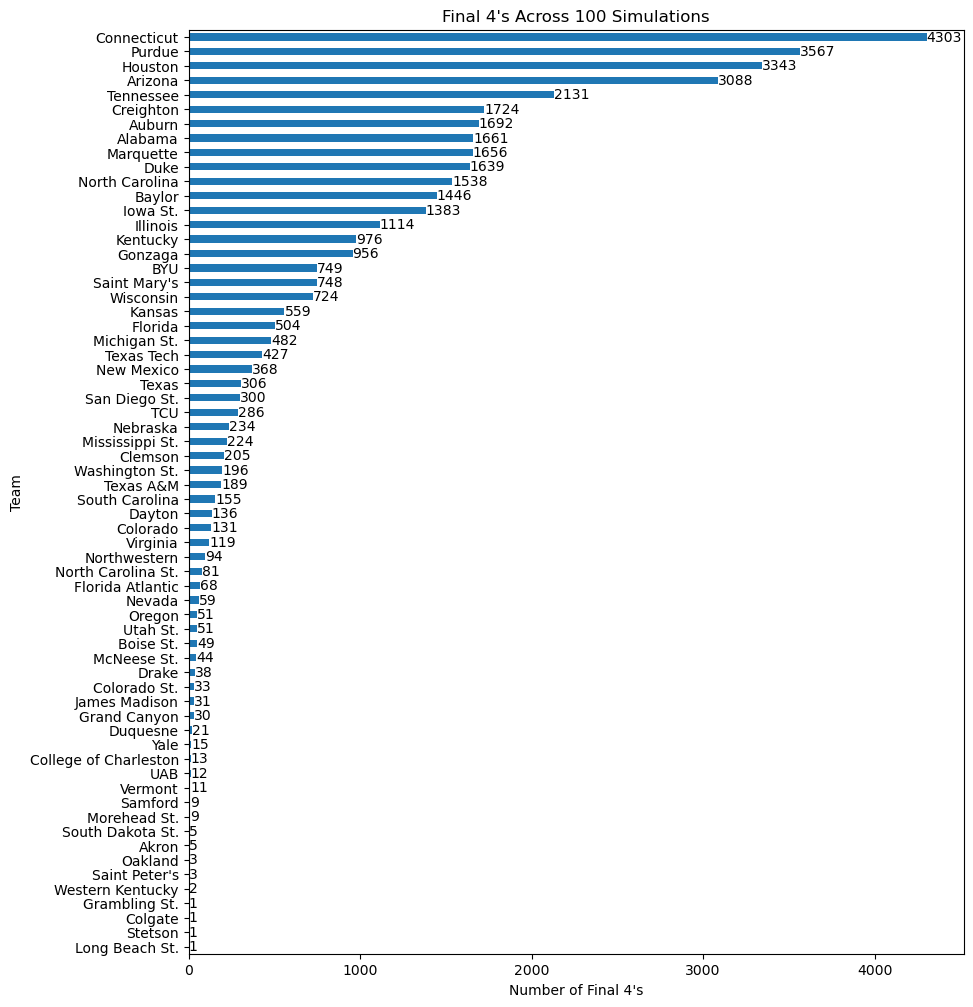

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Connecticut       4303 --> 43.03%          New Mexico        368 --> 3.68%            James Madison      31 --> 0.31%         
Purdue            3567 --> 35.67%          Texas             306 --> 3.06%            Grand Canyon       30 --> 0.3%          
Houston           3343 --> 33.43%          San Diego St.     300 --> 3.0%             Duquesne           21 --> 0.21%         
Arizona           3088 --> 30.88%          TCU               286 --> 2.86%            Yale               15 --> 0.15%         
Tennessee         2131 --> 21.31%          Nebraska          234 --> 2.34%            College of Charleston  13 --> 0.13%     
Creighton         1724 --> 17.24%          Mississippi St.   224 --> 2.24%            UAB                12 --> 0.12%         
Auburn            1692 --> 16.92%          Clemson           205 --> 2.05%            Vermont            11 --> 0.11%         
Alabama           1661 --> 16.61%          Washington St.    196 --> 1

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Connecticut       5732 --> 57.32%          Texas             1017 --> 10.17%          Colorado St.      140 --> 1.4%          
Purdue            5406 --> 54.06%          New Mexico        985 --> 9.85%            Duquesne          127 --> 1.27%         
Arizona           4937 --> 49.37%          Washington St.    962 --> 9.62%            James Madison      98 --> 0.98%         
Houston           4749 --> 47.49%          TCU               782 --> 7.82%            College of Charleston  84 --> 0.84%     
Tennessee         4169 --> 41.69%          San Diego St.     744 --> 7.44%            Morehead St.       67 --> 0.67%         
Marquette         3837 --> 38.37%          Mississippi St.   634 --> 6.34%            UAB                63 --> 0.63%         
Creighton         3479 --> 34.79%          South Carolina    596 --> 5.96%            Samford            56 --> 0.56%         
Alabama           3175 --> 31.75%          Clemson           586 --> 5

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Connecticut       8064 --> 80.64%          Michigan St.      2489 --> 24.89%          James Madison     543 --> 5.43%         
Arizona           7534 --> 75.34%          San Diego St.     2454 --> 24.54%          Boise St.         480 --> 4.8%          
Purdue            7459 --> 74.59%          Washington St.    2409 --> 24.09%          UAB               417 --> 4.17%         
Houston           7020 --> 70.2%           Texas             2358 --> 23.58%          Samford           384 --> 3.84%         
Creighton         6876 --> 68.76%          South Carolina    1929 --> 19.29%          Yale              368 --> 3.68%         
Auburn            6761 --> 67.61%          TCU               1850 --> 18.5%           Colorado St.      358 --> 3.58%         
Tennessee         6438 --> 64.38%          Clemson           1810 --> 18.1%           College of Charleston 340 --> 3.4%      
Iowa St.          6372 --> 63.72%          Mississippi St.   1669 -->

In [10]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
624824,9189,3.0,College of Charleston,13,0,6,100.000,N/A,16.405,Alabama,17.134,Saint Mary's,24.068,Michigan St.,11.761,Arizona,10.032,Connecticut,16.614,Houston,0.001
565488,8317,1.0,Akron,14,0,6,100.000,N/A,11.183,Creighton,16.972,South Carolina,10.208,Tennessee,40.377,Samford,17.474,Kentucky,14.146,Baylor,0.002
589168,8665,1.0,Utah St.,8,1,6,100.000,N/A,33.120,TCU,11.451,Purdue,25.092,Gonzaga,22.022,Creighton,18.561,Houston,10.103,Connecticut,0.004
356466,5243,1.0,Saint Peter's,15,0,5,100.000,N/A,10.614,Tennessee,17.344,Texas,22.724,Oregon,12.314,Purdue,9.490,Houston,17.108,Baylor,0.004
168984,2486,1.0,Grambling St.,16,0,4,50.037,Montana St.,8.145,Purdue,15.529,Utah St.,9.872,Kansas,10.408,Creighton,8.492,Duke,0.000,N/A,0.006
622500,9155,2.0,North Carolina St.,11,4,6,100.000,N/A,34.091,Texas Tech,27.317,Kentucky,20.645,Marquette,24.960,Wisconsin,14.487,Purdue,11.679,Connecticut,0.008
429584,6318,2.0,North Carolina St.,11,4,6,100.000,N/A,34.091,Texas Tech,27.317,Kentucky,20.645,Marquette,16.805,Duke,17.523,Tennessee,16.835,Auburn,0.010
118117,1738,1.0,Colorado St.,10,0,6,45.054,Virginia,33.276,Texas,17.559,Tennessee,24.738,Creighton,17.019,Purdue,31.627,Wisconsin,28.830,Alabama,0.010
509349,7491,2.0,Oakland,14,1,5,100.000,N/A,14.607,Kentucky,12.901,Texas Tech,54.191,Western Kentucky,10.392,Duke,11.383,Creighton,7.841,Connecticut,0.011
406424,5977,4.0,Duquesne,11,1,6,100.000,N/A,20.118,BYU,25.538,Illinois,45.239,Drake,10.258,Connecticut,22.958,Baylor,20.630,Gonzaga,0.011


In [15]:
df[df["sim_num"] == 3198].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
217450,3198,4.0,Connecticut,1,6,6,100.000,N/A,91.242,Stetson,90.160,Florida Atlantic,67.367,Auburn,75.470,Illinois,74.225,Alabama,62.06,Purdue,19.266
217405,3198,1.0,Purdue,1,5,5,100.000,N/A,90.231,Montana St.,88.549,Utah St.,85.771,McNeese St.,61.335,Tennessee,85.513,North Carolina St.,37.94,Connecticut,22.307
217424,3198,2.0,North Carolina St.,11,4,4,100.000,N/A,34.091,Texas Tech,27.317,Kentucky,20.645,Marquette,17.639,Houston,14.487,Purdue,0.00,N/A,0.290
217431,3198,3.0,Alabama,4,4,4,100.000,N/A,83.595,College of Charleston,74.288,Grand Canyon,59.083,North Carolina,46.637,Arizona,25.775,Connecticut,0.00,N/A,12.701
217418,3198,2.0,Houston,1,2,3,100.000,N/A,89.666,Longwood,77.783,Nebraska,67.757,Wisconsin,82.361,North Carolina St.,0.000,N/A,0.00,N/A,8.336
217454,3198,4.0,Illinois,3,3,3,100.000,N/A,82.944,Morehead St.,54.247,BYU,55.564,Iowa St.,24.530,Connecticut,0.000,N/A,0.00,N/A,18.868
217432,3198,3.0,Arizona,2,2,3,100.000,N/A,91.834,Long Beach St.,80.026,Dayton,58.103,Baylor,53.363,Alabama,0.000,N/A,0.00,N/A,19.914
217410,3198,1.0,Tennessee,2,3,3,100.000,N/A,89.386,Saint Peter's,82.441,Colorado St.,82.476,Oregon,38.665,Purdue,0.000,N/A,0.00,N/A,37.277
217430,3198,2.0,Wisconsin,5,0,2,100.000,N/A,75.972,James Madison,36.554,Duke,32.243,Houston,0.000,N/A,0.000,N/A,0.00,N/A,18.817
217448,3198,4.0,Auburn,4,0,2,100.000,N/A,87.372,Yale,86.261,UAB,32.633,Connecticut,0.000,N/A,0.000,N/A,0.00,N/A,50.773


In [11]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  742


In [12]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  2
[2985 3198]


In [16]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [17]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [18]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [13]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
458340,6741,2.0,Duke,4,3,6,100.000,N/A,86.606,Vermont,84.744,James Madison,70.889,Nebraska,51.301,Marquette,30.773,Purdue,52.111,Iowa St.,4.280
458379,6741,4.0,Iowa St.,2,2,5,100.000,N/A,86.051,South Dakota St.,78.339,Drake,49.221,BYU,46.914,Auburn,56.080,North Carolina,47.889,Duke,4.549
458329,6741,1.0,Purdue,1,5,4,100.000,N/A,91.855,Grambling St.,79.565,TCU,68.370,Kansas,80.785,Texas,69.227,Duke,0.000,N/A,12.422
458369,6741,3.0,North Carolina,1,2,4,100.000,N/A,90.139,Wagner,67.264,Mississippi St.,82.052,College of Charleston,51.493,Baylor,43.920,Iowa St.,0.000,N/A,14.366
458372,6741,4.0,Auburn,4,0,3,100.000,N/A,87.372,Yale,74.822,San Diego St.,79.226,Florida Atlantic,53.086,Iowa St.,0.000,N/A,0.000,N/A,24.298
458346,6741,2.0,Marquette,2,2,3,100.000,N/A,89.062,Western Kentucky,73.071,Boise St.,57.688,Kentucky,48.699,Duke,0.000,N/A,0.000,N/A,19.259
458357,6741,3.0,Baylor,3,1,3,100.000,N/A,82.220,Colgate,63.116,New Mexico,75.776,Nevada,48.507,North Carolina,0.000,N/A,0.000,N/A,20.249
458335,6741,1.0,Texas,7,1,3,100.000,N/A,57.116,Virginia,33.081,Tennessee,33.810,Creighton,19.215,Purdue,0.000,N/A,0.000,N/A,5.161
458373,6741,4.0,BYU,6,0,2,100.000,N/A,79.882,Duquesne,45.753,Illinois,50.779,Iowa St.,0.000,N/A,0.000,N/A,0.000,N/A,17.989
458344,6741,2.0,Kentucky,3,0,2,100.000,N/A,85.393,Oakland,72.683,North Carolina St.,42.312,Marquette,0.000,N/A,0.000,N/A,0.000,N/A,35.805


In [14]:
df.to_csv("../../data/2024_10000sims0.csv")